In [ ]:
#pip install scikit-learn


hola


In [2]:
import yaml
import torch
from astroclip.models import SpecFormer 
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import ast
import ast
import numpy as np
from lightning.fabric.utilities.data import AttributeDict
from lightning.fabric.utilities.data import AttributeDict
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import accuracy_score, f1_score


c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\fabric\__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\dinov2\layers\attention.py:33: UserWarning: xFormers is not availab

# DATOS 

In [3]:
df = pd.read_csv("DATOSFINAL.csv")
print(df["TType"].unique())
df.fillna(-99, inplace=True)
df['flux_plane_rest'] = df['flux_plane_rest'].apply(ast.literal_eval)
df['flux_plane_rest'] = df['flux_plane_rest'].apply(lambda x: np.array(x, dtype=np.float32))

# Tu DataFrame df y label_map
#label_map = {-5:0, -3:1, -2:2, 0:3, 1:4, 2:5, 3:6, 4:7, 5:8, 6:9, 7:10, 8:11, 9:12, 10:13,11:14, 99:15,-99:16}
label_map = {
    -5: 0,
    -3: 1, -2: 1, 0: 1,
    1: 2, 2: 2,
    3: 3, 4: 3,
    5: 4,
    6: 5, 7: 5, 8: 5, 9: 5, 10: 5
    , 99:15,-99:16
}
# Mapear los labels
df['clase'] = df['TType'].map(label_map)
mapped_labels = df['clase'].map(label_map)


#labels = torch.tensor(mapped_labels.values, dtype=torch.long)
#spectra = df['flux_plane_rest'].apply(lambda x: torch.tensor(x, dtype=torch.float32))


[ 5.  0. -5.  2.  3.  4.  6. 99.  1. -3. -2.  7. 10.  9. 11.  8.]


In [4]:
df.head(5)

,JID,TType,lamda_rest,flux_plane_rest,clase
0,J095410.49+021711.9,5.0,"[3513.693744899361, 3514.474613389082, 3515.25...","[-2.905335e-17, 4.506608e-17, 3.493662e-17, 7....",4.0
1,J095410.49+021711.9,5.0,"[3513.693744899361, 3514.474613389082, 3515.25...","[-2.3972938e-17, 3.951838e-17, 4.710383e-17, 1...",4.0
2,J095420.29+021751.25,0.0,"[3525.9549471089867, 3526.7385404766137, 3527....","[2.766418e-16, 3.136982e-16, 3.1239427e-16, 3....",1.0
3,J095420.29+021751.25,0.0,"[3525.9549471089867, 3526.7385404766137, 3527....","[1.5579568e-17, 7.506545e-17, 1.126405e-16, -1...",1.0
4,J095521.08+030957.22,5.0,"[3422.053228449178, 3422.813731136734, 3423.57...","[-2.0947108e-16, 9.4183526e-17, -3.4928198e-17...",4.0


In [3]:

from astroclip.models.astroclip import (
    AstroClipModel,
    ImageHead,
    SpectrumHead,
    CLIPLoss
)
from astroclip.modules import MLP, CrossAttentionHead
from astroclip.models.specformer import SpecFormer

# 1. Permitimos las clases del checkpoint
torch.serialization.add_safe_globals([
    AstroClipModel,
    ImageHead,
    SpectrumHead,
    SpecFormer,
    CLIPLoss,
    MLP,
    CrossAttentionHead
])

# 2. Cargamos el checkpoint
ckpt = torch.load("astroclip.ckpt", map_location="cpu", weights_only=False)

# 3. Recuperamos hyperparameters
hparams = ckpt["hyper_parameters"]

# 4. Inicializamos el modelo con los hyperparams del checkpoint
model = AstroClipModel(**hparams)

# 5. Restauramos pesos
model.load_state_dict(ckpt["state_dict"], strict=True)

model.eval()




c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['spectrum_encoder'])`.


AstroClipModel(
  (image_encoder): ImageHead(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(12, 12), stride=(12, 12))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0): BlockChunk(
          (0-5): 6 x NestedTensorBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4096, bias=True)
              (act): GELU(approximate='none'

In [6]:
for param in model.parameters():
    param.requires_grad = False


In [7]:
import torch.nn as nn

class MorphologyClassifier(nn.Module):
    def __init__(self, input_dim=2048, num_classes=17):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
clf = MorphologyClassifier(input_dim=2048, num_classes=len(label_map))
clf = clf.to("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F
patch_size = 12
new_size = (patch_size * (224 // patch_size), patch_size * (224 // patch_size))  # (216, 216)

img_transform = transforms.Compose([
    transforms.Resize(new_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


def embed_image(path, device="cuda"):
    img = Image.open(path).convert("RGB")
    img = img_transform(img).unsqueeze(0).to(device)  # (1, C, H, W)

    # Duplicar la imagen para batch=2
    img = torch.cat([img, img], dim=0)

    with torch.no_grad():
        output = model.image_encoder(img)

        # Tomar solo la primera
        if isinstance(output, tuple):
            e = output[0][0]
        else:
            e = output[0]

    return e.squeeze(0)

In [10]:
import numpy as np
import torch

def preprocess_spectrum(wavelengths, flux):
    """
    Preprocesamiento EXACTO estilo AstroCLIP:
      - Interpolación a 1024 bins
      - Normalización por mediana
      - Clipping (-5,5)
      - Normalización estándar
      - Canal adicional: gradiente espectral
      - Output shape: (2, 1024)
    """

    # --- 1. Rejilla estándar de AstroCLIP ---
    lambda_min = 3600
    lambda_max = 10400
    n_bins = 1024

    target_wave = np.linspace(lambda_min, lambda_max, n_bins)

    # --- 2. Interpolar ---
    flux_interp = np.interp(target_wave, wavelengths, flux)

    # --- 3. Normalización por mediana ---
    med = np.median(flux_interp)
    if med == 0 or np.isnan(med):
        med = 1.0

    flux_norm = flux_interp / med

    # --- 4. Clipping ---
    flux_norm = np.clip(flux_norm, -5, 5)

    # --- 5. Manejo de NaNs ---
    flux_norm = np.nan_to_num(flux_norm, nan=0.0)

    # --- 6. Normalización estándar ---
    mean = flux_norm.mean()
    std = flux_norm.std() if flux_norm.std() > 0 else 1.0
    flux_standard = (flux_norm - mean) / std

    # --- 7. Canal adicional: gradiente espectral ---
    grad = np.gradient(flux_standard)

    # --- 8. Empaquetar en tensor 2 x 1024 ---
    spec_tensor = np.stack([flux_standard, grad], axis=0)

    return torch.tensor(spec_tensor, dtype=torch.float32)


def embed_spectrum(spec):
    # Aceptar numpy o tensor
    if isinstance(spec, np.ndarray):
        spec = torch.tensor(spec, dtype=torch.float32)

    # Si viene en forma (2, L) o cualquier forma 2D → aplanar
    if spec.dim() == 2:
        spec = spec.reshape(-1)  # <- convierte (2,1024) en (2048,)

    # Debe quedar 1D
    if spec.dim() != 1:
        raise ValueError(f"El espectro debe ser 1D, pero llegó como {spec.shape}")

    # Convertir a (1, L, 1)
    spec = spec.unsqueeze(0).unsqueeze(-1).to(device)

    # Padding
    slice_len = model.spectrum_encoder.backbone.hparams.slice_section_length
    L = spec.shape[1]
    pad_len = (slice_len - (L % slice_len)) % slice_len
    if pad_len > 0:
        spec = F.pad(spec, (0, 0, 0, pad_len), "constant", 0.0)

    # Evitar error CrossAttention
    if spec.shape[0] == 1:
        spec2 = spec.repeat(2, 1, 1)
        with torch.no_grad():
            e = model.spectrum_encoder(spec2, return_weights=False)
        e = e[0].unsqueeze(0)
    else:
        with torch.no_grad():
            e = model.spectrum_encoder(spec, return_weights=False)

    return e.squeeze(0)




In [11]:
print(df['flux_plane_rest'].iloc[0])
print(type(df['flux_plane_rest'].iloc[0]))
print(df["flux_plane_rest"].shape)
print(df["lamda_rest"].shape, df["flux_plane_rest"].shape)


[-2.9053349e-17  4.5066080e-17  3.4936618e-17 ... -9.4307068e-18
  2.7563623e-18 -4.6305186e-18]
<class 'numpy.ndarray'>
(1271,)
(1271,) (1271,)


In [12]:
print(df['flux_plane_rest'].iloc[0])
print(type(df['flux_plane_rest'].iloc[0]))


[-2.9053349e-17  4.5066080e-17  3.4936618e-17 ... -9.4307068e-18
  2.7563623e-18 -4.6305186e-18]
<class 'numpy.ndarray'>


# CLIP

In [13]:
import os
import ast

def to_array(x):
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    raise ValueError(f"Tipo inesperado: {type(x)}")

all_SPECTROS = []
all_IMAGENES = []
spectrum_jids = []
image_jids = []


for idx, row in df.iterrows():
    print(idx)
    wave = to_array(row['lamda_rest'])
    flux = to_array(row['flux_plane_rest'])
 
    spectrum = preprocess_spectrum(wave,flux )
    #print("spectrum antes:", spectrum.shape)
    jid = row["JID"]
    
    img_path = f"imagenes/{jid}.jpg"

    if not os.path.exists(img_path):
        #print(f"Imagen no encontrada para JID {jid}, se omite.")
        continue

    spec_emb = embed_spectrum(spectrum)
    img_emb  = embed_image(img_path, device)

    all_SPECTROS.append(spec_emb)
    all_IMAGENES.append(img_emb)

    #  esto es lo que te faltaba
    spectrum_jids.append(jid)
    image_jids.append(jid)





0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [14]:


all_SPECTROS_to = torch.cat(all_SPECTROS, dim=0)  # shape: (N, D)
all_IMAGENES_to = torch.cat(all_IMAGENES, dim=0)  # shape: (N, D)
D = 1024
all_SPECTROS_to = all_SPECTROS_to.view(-1, D)  # ahora (N, D)
all_IMAGENES_to = all_IMAGENES_to.view(-1, D)

all_SPECTROS_norm = all_SPECTROS_to / all_SPECTROS_to.norm(dim=-1, keepdim=True)
all_IMAGENES_norm = all_IMAGENES_to / all_IMAGENES_to.norm(dim=-1, keepdim=True)


In [15]:
print(all_SPECTROS_norm.shape)
print(all_IMAGENES_norm.shape)

torch.Size([1252, 1024])
torch.Size([1252, 1024])


In [16]:
similarity_matrix = all_SPECTROS_norm @ all_IMAGENES_norm.T  # producto punto
# si normalizaste antes, esto es equivalente a coseno
print(similarity_matrix.shape) 

torch.Size([1252, 1252])


In [17]:
correctos = 0

for i in range(len(spectrum_jids)):
    pred = int(similarity_matrix[i].argmax())
    if pred == i:  
        correctos += 1

print("Accuracy de recuperación 1:1 =", correctos, "/", len(spectrum_jids))


Accuracy de recuperación 1:1 = 1 / 1252


In [18]:
correctos_tipo = 0

for i in range(len(spectrum_jids)):
    pred = int(similarity_matrix[i].argmax())
    
    spec_type = df.loc[df["JID"] == spectrum_jids[i], "clase"].iloc[0]
    img_type  = df.loc[df["JID"] == image_jids[pred], "clase"].iloc[0]
    
    if spec_type == img_type:
        correctos_tipo += 1

print("Accuracy por tipo espectral:", correctos_tipo, "/", len(spectrum_jids))


Accuracy por tipo espectral: 144 / 1252


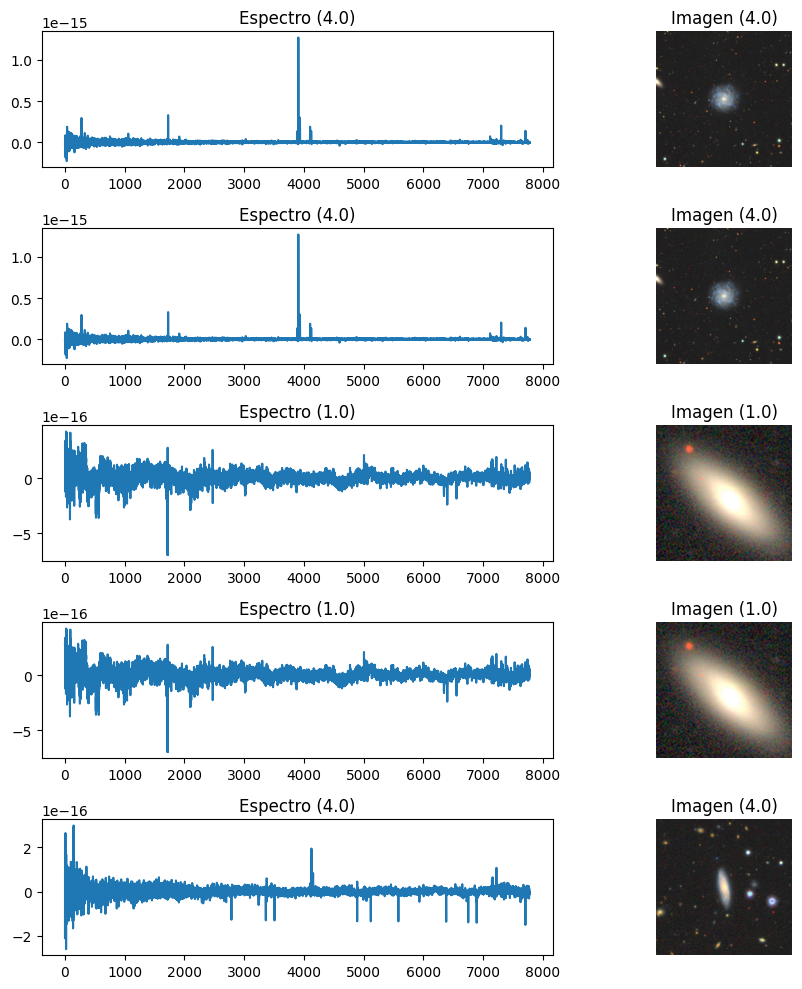

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Carpeta donde están las imágenes
img_dir = "imagenes"

# Número de ejemplos a mostrar
n_examples = 5  # puedes cambiarlo al total o a los que quieras inspeccionar

plt.figure(figsize=(10, 2 * n_examples))

for i in range(n_examples):
    jid = spectrum_jids[i]  # mismo JID para espectro e imagen
    
    # Extraer espectro del DataFrame
    spectrum = df.loc[df["JID"] == jid, "flux_plane_rest"].values[0]  # cambia "spectrum_column" por el nombre real de la columna de espectros
    spec_type = df.loc[df["JID"] == jid, "clase"].iloc[0]
    
    # Cargar imagen
    img_path = os.path.join(img_dir, f"{jid}.jpg")
    img = mpimg.imread(img_path)
    
    # Mostrar espectro
    plt.subplot(n_examples, 2, 2*i+1)
    plt.plot(spectrum)
    plt.title(f"Espectro ({spec_type})")
    
    # Mostrar imagen
    plt.subplot(n_examples, 2, 2*i+2)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Imagen ({spec_type})")

plt.tight_layout()
plt.show()



In [20]:
'''import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def mostrar_img_y_espectro(jid_img, jid_spec, spectrum_vector):
    img_path = f"imagenes/{jid_img}.jpg"   # o png, cambia si es necesario
    img = Image.open(img_path)

    plt.figure(figsize=(10,4))

    # ---- Imagen ----
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Imagen JID {jid_img}")

    # ---- Espectro ----
    plt.subplot(1, 2, 2)
    plt.plot(spectrum_vector)
    plt.title(f"Espectro JID {jid_spec}")
    plt.xlabel("Pixel / Canal")
    plt.ylabel("Intensidad")

    plt.tight_layout()
    plt.show()


for i in range(5):  
    pred = int(similarity_matrix[i].argmax())

    jid_spec = spectrum_jids[i]
    jid_img  = image_jids[pred]

    spectrum_vector = spectra[i]  

    mostrar_img_y_espectro(jid_img, jid_spec, spectrum_vector)'''


'import matplotlib.pyplot as plt\nfrom PIL import Image\nimport numpy as np\n\ndef mostrar_img_y_espectro(jid_img, jid_spec, spectrum_vector):\n    img_path = f"imagenes/{jid_img}.jpg"   # o png, cambia si es necesario\n    img = Image.open(img_path)\n\n    plt.figure(figsize=(10,4))\n\n    # ---- Imagen ----\n    plt.subplot(1, 2, 1)\n    plt.imshow(img)\n    plt.axis("off")\n    plt.title(f"Imagen JID {jid_img}")\n\n    # ---- Espectro ----\n    plt.subplot(1, 2, 2)\n    plt.plot(spectrum_vector)\n    plt.title(f"Espectro JID {jid_spec}")\n    plt.xlabel("Pixel / Canal")\n    plt.ylabel("Intensidad")\n\n    plt.tight_layout()\n    plt.show()\n\n\nfor i in range(5):  \n    pred = int(similarity_matrix[i].argmax())\n\n    jid_spec = spectrum_jids[i]\n    jid_img  = image_jids[pred]\n\n    spectrum_vector = spectra[i]  \n\n    mostrar_img_y_espectro(jid_img, jid_spec, spectrum_vector)'

In [21]:
import pandas as pd

filas_a_guardar = []

for idx, row in df.iterrows():
    jid = row["JID"]
    
    img_path = f"imagenes/{jid}.jpg"
    if not os.path.exists(img_path):
        print(f"Imagen no encontrada para JID {jid}, se omite.")
    else:
        filas_a_guardar.append(row.to_dict())
        
df_guardar = pd.DataFrame(filas_a_guardar)



Imagen no encontrada para JID J095905.51+023809.91, se omite.
Imagen no encontrada para JID J095905.51+023809.91, se omite.
Imagen no encontrada para JID J125718.25+274450.4, se omite.
Imagen no encontrada para JID J125718.25+274450.4, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125818.62+271838.9, se omite.
Imagen no encontrada para JID J125818.62+271838.9, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J140423.57+044304.45, se omite.
Imagen no encontrada 

In [22]:
print(df_guardar["JID"])

0        J095410.49+021711.9
1        J095410.49+021711.9
2       J095420.29+021751.25
3       J095420.29+021751.25
4       J095521.08+030957.22
                ...         
1247     J165613.04+333526.1
1248     J165646.78+350253.1
1249     J165654.16+335430.9
1250     J165714.40+340122.9
1251     J165714.40+340122.9
Name: JID, Length: 1252, dtype: object


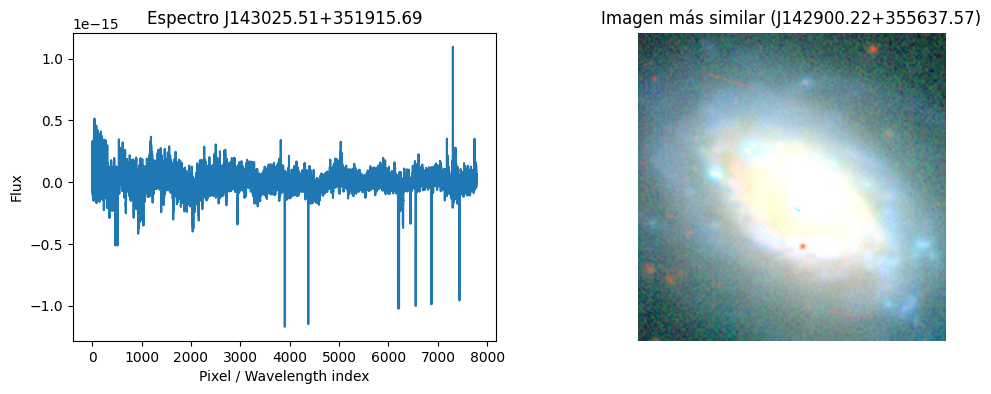

144


In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
z=0
for i in range(len(df_guardar)):
    
    # Índice del espectro que quieres comprobar
    idx_spectrum = i

    # Imagen más similar según embeddings
    most_similar_idx = int(similarity_matrix[idx_spectrum].argmax())  # <-- convertimos a int

    # Obtenemos el espectro y la imagen correspondientes
    # Usar el espectro original
    spectrum = df_guardar.iloc[idx_spectrum]["flux_plane_rest"]  # ya es un vector numpy o lista

    img_path = f"imagenes/{df_guardar.iloc[most_similar_idx]['JID']}.jpg"
    img = mpimg.imread(img_path)
    
    #print(df_guardar.iloc[idx_spectrum]["clase"])
    #print(df_guardar.iloc[most_similar_idx]['clase'])
    
    if df_guardar.iloc[most_similar_idx]['clase']==df_guardar.iloc[idx_spectrum]["clase"]:
        z=z+1
    
    if df_guardar.iloc[idx_spectrum]["JID"]==df_guardar.iloc[most_similar_idx]['JID']:
    # Visualizamos lado a lado
        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        plt.plot(spectrum)
        plt.xlabel("Pixel / Wavelength index")
        plt.ylabel("Flux")
        plt.title(f"Espectro {df_guardar.iloc[idx_spectrum]["JID"]}")

        plt.subplot(1,2,2)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Imagen más similar ({df.iloc[most_similar_idx]['JID']})")

        plt.show()
print(z)


# pruebas de morfologia

In [24]:

all_features = []
all_labels = []

for idx, row in df.iterrows():
    spectrum = torch.tensor(row["flux_plane_rest"], dtype=torch.float32)
    
    jid = row["JID"]
    
    img_path = f"imagenes/{jid}.jpg"
    if not os.path.exists(img_path):
        print(f"Imagen no encontrada para JID {jid}, se omite.")
    else:
        spec_emb = embed_spectrum(spectrum)

        img_emb  = embed_image(img_path,device)

        fused = torch.cat([spec_emb, img_emb], dim=-1)  # (1024,)

        all_features.append(fused)
        all_labels.append(label_map[row["clase"]])


Imagen no encontrada para JID J095905.51+023809.91, se omite.
Imagen no encontrada para JID J095905.51+023809.91, se omite.
Imagen no encontrada para JID J125718.25+274450.4, se omite.
Imagen no encontrada para JID J125718.25+274450.4, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125723.56+273259.7, se omite.
Imagen no encontrada para JID J125818.62+271838.9, se omite.
Imagen no encontrada para JID J125818.62+271838.9, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J130305.74+252830.5, se omite.
Imagen no encontrada para JID J140423.57+044304.45, se omite.
Imagen no encontrada 

In [25]:
X = torch.stack(all_features)   # (N, 1024)
y = torch.tensor(all_labels)    # (N,)


In [26]:
print(all_features[0].shape)  # debe ser torch.Size([1024])


torch.Size([2048])


In [27]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X, y)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss()
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
device = "cuda" if torch.cuda.is_available() else "cpu"

clf.train()
for epoch in range(20):
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        opt.zero_grad()
        logits = clf(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print("Epoch", epoch, "loss", total_loss/len(loader))


Epoch 0 loss 1.4151614889502526
Epoch 1 loss 1.0868081539869308
Epoch 2 loss 1.0276032000780106
Epoch 3 loss 0.9940307199954986
Epoch 4 loss 0.961662732064724
Epoch 5 loss 0.9460643887519836
Epoch 6 loss 0.9302917361259461
Epoch 7 loss 0.8922823503613472
Epoch 8 loss 0.9089932814240456
Epoch 9 loss 0.8779959477484226
Epoch 10 loss 0.9074934914708137
Epoch 11 loss 0.8796551778912545
Epoch 12 loss 0.8830620810389519
Epoch 13 loss 0.8945257633924484
Epoch 14 loss 0.8685408592224121
Epoch 15 loss 0.863655960559845
Epoch 16 loss 0.8859869301319122
Epoch 17 loss 0.9076427221298218
Epoch 18 loss 0.875769853591919
Epoch 19 loss 0.8586963675916195


Epoch 1/50 - Loss: 2.2045 - Val Accuracy: 0.4781
Epoch 2/50 - Loss: 1.5760 - Val Accuracy: 0.4781
Epoch 3/50 - Loss: 1.3781 - Val Accuracy: 0.4781
Epoch 4/50 - Loss: 1.2998 - Val Accuracy: 0.4781
Epoch 5/50 - Loss: 1.2432 - Val Accuracy: 0.4781
Epoch 6/50 - Loss: 1.2146 - Val Accuracy: 0.4781
Epoch 7/50 - Loss: 1.1897 - Val Accuracy: 0.4781
Epoch 8/50 - Loss: 1.1795 - Val Accuracy: 0.4781
Epoch 9/50 - Loss: 1.1623 - Val Accuracy: 0.4781
Epoch 10/50 - Loss: 1.1771 - Val Accuracy: 0.4781
Epoch 11/50 - Loss: 1.1478 - Val Accuracy: 0.4781
Epoch 12/50 - Loss: 1.1352 - Val Accuracy: 0.4781
Epoch 13/50 - Loss: 1.1298 - Val Accuracy: 0.5219
Epoch 14/50 - Loss: 1.1349 - Val Accuracy: 0.5179
Epoch 15/50 - Loss: 1.1516 - Val Accuracy: 0.4781
Epoch 16/50 - Loss: 1.1179 - Val Accuracy: 0.4781
Epoch 17/50 - Loss: 1.1142 - Val Accuracy: 0.5060
Epoch 18/50 - Loss: 1.1084 - Val Accuracy: 0.4821
Epoch 19/50 - Loss: 1.1162 - Val Accuracy: 0.5259
Epoch 20/50 - Loss: 1.0986 - Val Accuracy: 0.5179
Epoch 21/

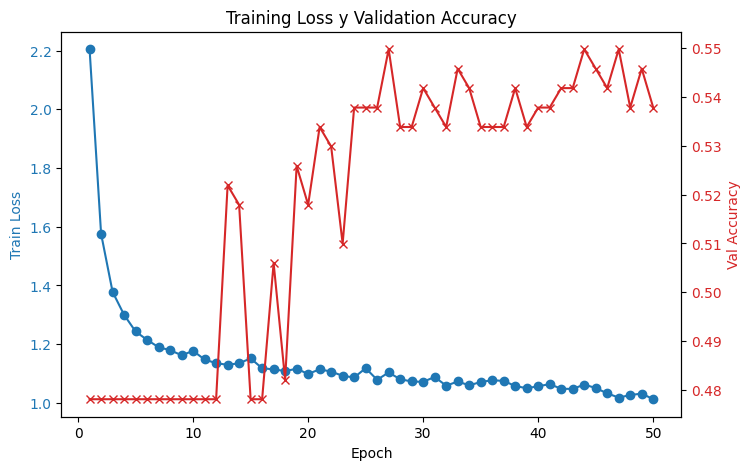

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Convertir listas a tensores
X = torch.stack(all_features)  # fused embeddings, tamaño (N, 2048)
y = torch.tensor(all_labels)   # etiquetas, tamaño (N,)

# Dividir en train/test (80/20)
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Definir modelo
clf = MorphologyClassifier(input_dim=X.shape[1], num_classes=len(label_map))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clf.to(device)

# Loss y optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-5)



# Listas para guardar métricas
train_losses = []
val_accuracies = []

epochs = 50
for epoch in range(epochs):
    clf.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = clf(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validación
    clf.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = clf(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    val_acc = accuracy_score(all_targets, all_preds)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - Val Accuracy: {val_acc:.4f}")

# Graficar Loss y Accuracy
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(range(1, epochs+1), train_losses, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # segundo eje y
color = 'tab:red'
ax2.set_ylabel('Val Accuracy', color=color)
ax2.plot(range(1, epochs+1), val_accuracies, color=color, marker='x')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss y Validation Accuracy')
plt.show()



# DISTRIBUCION DE CLASES

1271
clase
1.0     354
2.0     273
3.0     248
0.0     184
4.0     118
5.0      75
15.0      6
Name: count, dtype: int64


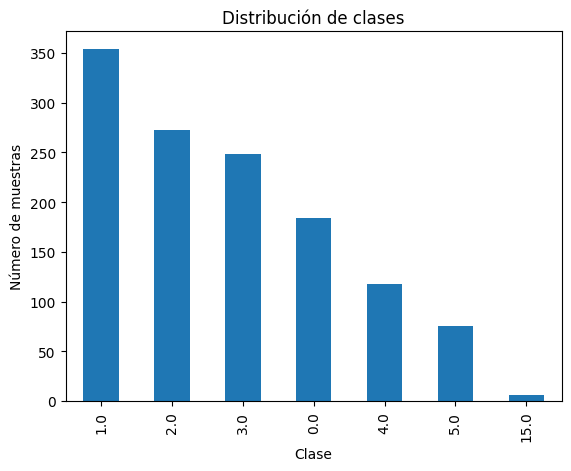

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd

img_dir = "imagenes"


#df_filtrado = df[df["JID"].apply(lambda jid: os.path.exists(os.path.join(img_dir, f"{jid}.jpg")))]

#df_filtrado.to_csv("datosusados.csv")
#df_filtrado=pd.read_csv("datosusados.csv")
# Contar cuántas muestras hay de cada clase
conteo = df['clase'].value_counts()
print(len(df))
print(conteo)


# Graficar la distribución
conteo.plot(kind='bar')
plt.xlabel('Clase')
plt.ylabel('Número de muestras')
plt.title('Distribución de clases')
plt.show()


In [30]:
df.head(5)

,JID,TType,lamda_rest,flux_plane_rest,clase
0,J095410.49+021711.9,5.0,"[3513.693744899361, 3514.474613389082, 3515.25...","[-2.905335e-17, 4.506608e-17, 3.493662e-17, 7....",4.0
1,J095410.49+021711.9,5.0,"[3513.693744899361, 3514.474613389082, 3515.25...","[-2.3972938e-17, 3.951838e-17, 4.710383e-17, 1...",4.0
2,J095420.29+021751.25,0.0,"[3525.9549471089867, 3526.7385404766137, 3527....","[2.766418e-16, 3.136982e-16, 3.1239427e-16, 3....",1.0
3,J095420.29+021751.25,0.0,"[3525.9549471089867, 3526.7385404766137, 3527....","[1.5579568e-17, 7.506545e-17, 1.126405e-16, -1...",1.0
4,J095521.08+030957.22,5.0,"[3422.053228449178, 3422.813731136734, 3423.57...","[-2.0947108e-16, 9.4183526e-17, -3.4928198e-17...",4.0


# aqui obtenemos el encoder de espectros de astroclip

In [4]:


# Inicializar spectrum_encoder primero
spectrum_encoder = SpecFormer(
    input_dim=22,
    embed_dim=768,
    num_layers=6,
    num_heads=6,
    max_len=7781,
    dropout=0.1
)

# Cargar checkpoint permitiendo AttributeDict
with torch.serialization.safe_globals([AttributeDict]):
    checkpoint = torch.load("specformer.ckpt", map_location="cpu", weights_only=False)

# Extraer state_dict
state_dict = checkpoint.get("state_dict", checkpoint)

# Filtrar solo los pesos del spectrum_encoder
spectrum_state_dict = {
    k.replace("spectrum_encoder.", ""): v
    for k, v in state_dict.items() if "spectrum_encoder." in k
}

# Cargar los pesos en el encoder
spectrum_encoder.load_state_dict(spectrum_state_dict, strict=False)

# Inicializar el modelo completo



#epochs = 30


_IncompatibleKeys(missing_keys=['data_embed.weight', 'data_embed.bias', 'position_embed.weight', 'blocks.0.layernorm1.weight', 'blocks.0.layernorm1.bias', 'blocks.0.attention.attention.weight', 'blocks.0.attention.attention.bias', 'blocks.0.attention.projection.weight', 'blocks.0.attention.projection.bias', 'blocks.0.layernorm2.weight', 'blocks.0.layernorm2.bias', 'blocks.0.mlp.encoder.weight', 'blocks.0.mlp.encoder.bias', 'blocks.0.mlp.decoder.weight', 'blocks.0.mlp.decoder.bias', 'blocks.1.layernorm1.weight', 'blocks.1.layernorm1.bias', 'blocks.1.attention.attention.weight', 'blocks.1.attention.attention.bias', 'blocks.1.attention.projection.weight', 'blocks.1.attention.projection.bias', 'blocks.1.layernorm2.weight', 'blocks.1.layernorm2.bias', 'blocks.1.mlp.encoder.weight', 'blocks.1.mlp.encoder.bias', 'blocks.1.mlp.decoder.weight', 'blocks.1.mlp.decoder.bias', 'blocks.2.layernorm1.weight', 'blocks.2.layernorm1.bias', 'blocks.2.attention.attention.weight', 'blocks.2.attention.attent

In [5]:

df = pd.read_csv("DATOSFINAL.csv")
print(df["TType"].unique())
df.fillna(-99, inplace=True)
df['flux_plane_rest'] = df['flux_plane_rest'].apply(ast.literal_eval)
df['flux_plane_rest'] = df['flux_plane_rest'].apply(lambda x: np.array(x, dtype=np.float32))

# Tu DataFrame df y label_map
label_map = {
    -5: 0,
    -3: 1, -2: 1, 0: 1,
    1: 2, 2: 2,
    3: 3, 4: 3,
    5: 4,
    6: 5, 7: 5, 8: 5, 9: 5, 10: 5
    , 99:15,-99:16
}
# Mapear los labels

df['clase'] = df['TType'].map(label_map)
mapped_labels = df['clase'].map(label_map)


labels = torch.tensor(mapped_labels.values, dtype=torch.long)
spectra = df['flux_plane_rest'].apply(lambda x: torch.tensor(x, dtype=torch.float32))

spectra_train, spectra_test, labels_train, labels_test = train_test_split(
    spectra, labels, test_size=0.2, random_state=42, stratify=labels
)


class SpectrumDataset(Dataset):
    def __init__(self, spectra, labels):
        self.spectra = list(spectra)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.spectra)

    def __getitem__(self, idx):
        return self.spectra[idx], self.labels[idx]

dataset = SpectrumDataset(spectra, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Crear datasets
train_dataset = SpectrumDataset(spectra_train, labels_train)
test_dataset  = SpectrumDataset(spectra_test, labels_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


[ 5.  0. -5.  2.  3.  4.  6. 99.  1. -3. -2.  7. 10.  9. 11.  8.]


C:\Users\PabloL\AppData\Local\Temp\3\ipykernel_14268\238013357.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


In [6]:
# Mover modelo a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Definir optimizador y función de pérdida
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-1,
    betas=(0.9, 0.95)
)

criterion = torch.nn.CrossEntropyLoss() 

In [7]:
import torch.nn as nn


embedding_dim = 768
num_classes = 17  # ajusta según tus etiquetas

classifier_head = nn.Sequential(
    nn.Linear(embedding_dim, 512),
    nn.ReLU(),
    nn.Linear(512, num_classes)  # output [B, num_classes]
).to(device)


model.train()  # activar modo entrenamiento

AstroClipModel(
  (image_encoder): ImageHead(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(12, 12), stride=(12, 12))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0): BlockChunk(
          (0-5): 6 x NestedTensorBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4096, bias=True)
              (act): GELU(approximate='none'

In [10]:


epochs=50

for epoch in range(epochs):
    running_loss = 0.0
    for batch_spectra, batch_labels in dataloader:
        batch_spectra = batch_spectra.unsqueeze(-1).to(device)  # [B, L, 1]
        batch_labels = batch_labels.to(device)                  # [B]

        optimizer.zero_grad()

        # Obtener embeddings
        outputs = model.spectrum_encoder(batch_spectra)
        embeddings = outputs['embedding']                       # [B, embedding_dim]

        
        logits = classifier_head(embeddings)                   # [B, num_classes]
        logits = logits[:, 0, :] 
        # Calcular loss
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(dataloader):.4f}")



C:\Users\PabloL\AppData\Local\Temp\3\ipykernel_14268\1605355704.py:13: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:351.)
  embeddings = outputs['embedding']                       # [B, embedding_dim]


IndexError: too many indices for tensor of dimension 2

Epoch 1/30 | Train Loss: 2.3743 | Train Acc: 0.1714 | Train F1: 0.0531 | Val Loss: 2.3328 | Val Acc: 0.1992 | Val F1: 0.0575
Epoch 2/30 | Train Loss: 2.3385 | Train Acc: 0.1910 | Train F1: 0.0593 | Val Loss: 2.3197 | Val Acc: 0.2070 | Val F1: 0.0538
Epoch 3/30 | Train Loss: 2.3211 | Train Acc: 0.1841 | Train F1: 0.0630 | Val Loss: 2.3061 | Val Acc: 0.1914 | Val F1: 0.0554
Epoch 4/30 | Train Loss: 2.3163 | Train Acc: 0.1753 | Train F1: 0.0580 | Val Loss: 2.2948 | Val Acc: 0.2031 | Val F1: 0.0609
Epoch 5/30 | Train Loss: 2.3121 | Train Acc: 0.1783 | Train F1: 0.0525 | Val Loss: 2.2800 | Val Acc: 0.2070 | Val F1: 0.0578
Epoch 6/30 | Train Loss: 2.2980 | Train Acc: 0.1773 | Train F1: 0.0533 | Val Loss: 2.2817 | Val Acc: 0.1914 | Val F1: 0.0551
Epoch 7/30 | Train Loss: 2.2902 | Train Acc: 0.1900 | Train F1: 0.0583 | Val Loss: 2.2703 | Val Acc: 0.1992 | Val F1: 0.0571
Epoch 8/30 | Train Loss: 2.2886 | Train Acc: 0.1939 | Train F1: 0.0575 | Val Loss: 2.2686 | Val Acc: 0.1719 | Val F1: 0.0456


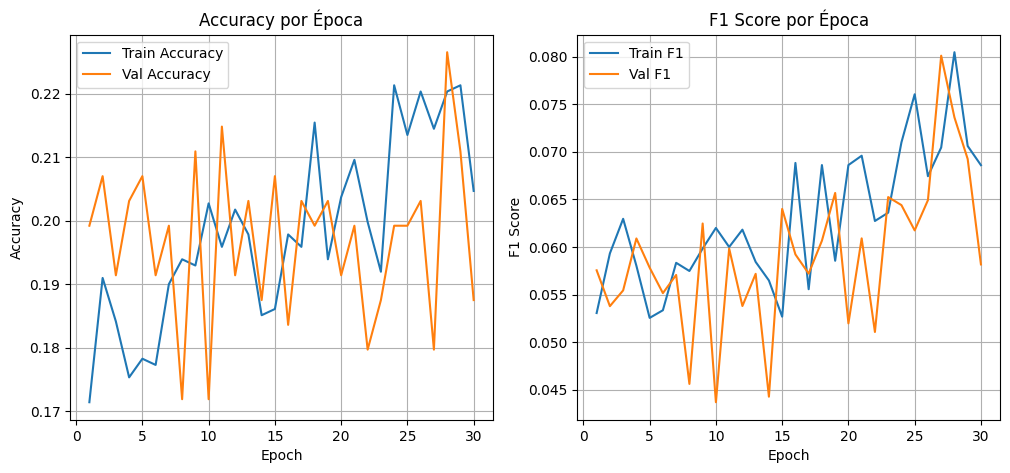

In [ ]:


# Listas para guardar métricas
train_acc_list, val_acc_list = [], []
train_f1_list, val_f1_list = [], []
model.train()
classifier_head.train()
for epoch in range(epochs):
    
    

    running_loss = 0.0
    train_preds, train_labels = [], []

    for spectra, labels in train_loader:
        spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
        optimizer.zero_grad()

        
        emb = model.spectrum_encoder(spectra)["embedding"]

        logits = classifier_head(emb)
       # print(logits.shape)
        logits = logits[:, 0, :] 
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    train_acc_list.append(train_acc)
    train_f1_list.append(train_f1)

    # ---- VALIDATION ----
    model.eval()
    classifier_head.eval()

    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for spectra, labels in test_loader:
            spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
            emb = model.spectrum_encoder(spectra)["embedding"]
            logits = classifier_head(emb)
            logits = logits[:, 0, :] 
            loss = criterion(logits, labels)
            val_loss += loss.item()

            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_acc_list.append(val_acc)
    val_f1_list.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ---- GRAFICAR METRICAS ----
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_acc_list, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por Época")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_f1_list, label="Train F1")
plt.plot(range(1, epochs+1), val_f1_list, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score por Época")
plt.legend()
plt.grid(True)

plt.show()


Epoch 1/10 | Train Loss: 2.2191 | Train Acc: 0.2027 | Train F1: 0.0765 | Val Loss: 2.2108 | Val Acc: 0.2109 | Val F1: 0.0889
Epoch 2/10 | Train Loss: 2.1845 | Train Acc: 0.2243 | Train F1: 0.0848 | Val Loss: 2.2057 | Val Acc: 0.1836 | Val F1: 0.0776
Epoch 3/10 | Train Loss: 2.1906 | Train Acc: 0.2135 | Train F1: 0.0852 | Val Loss: 2.2118 | Val Acc: 0.2188 | Val F1: 0.0834
Epoch 4/10 | Train Loss: 2.1831 | Train Acc: 0.2233 | Train F1: 0.0887 | Val Loss: 2.2060 | Val Acc: 0.2070 | Val F1: 0.0882
Epoch 5/10 | Train Loss: 2.1801 | Train Acc: 0.2184 | Train F1: 0.0819 | Val Loss: 2.2157 | Val Acc: 0.1992 | Val F1: 0.0784
Epoch 6/10 | Train Loss: 2.1785 | Train Acc: 0.2057 | Train F1: 0.0815 | Val Loss: 2.2144 | Val Acc: 0.2031 | Val F1: 0.0690
Epoch 7/10 | Train Loss: 2.1858 | Train Acc: 0.2096 | Train F1: 0.0792 | Val Loss: 2.2550 | Val Acc: 0.1797 | Val F1: 0.0457
Epoch 8/10 | Train Loss: 2.1970 | Train Acc: 0.2047 | Train F1: 0.0762 | Val Loss: 2.1977 | Val Acc: 0.2344 | Val F1: 0.1037


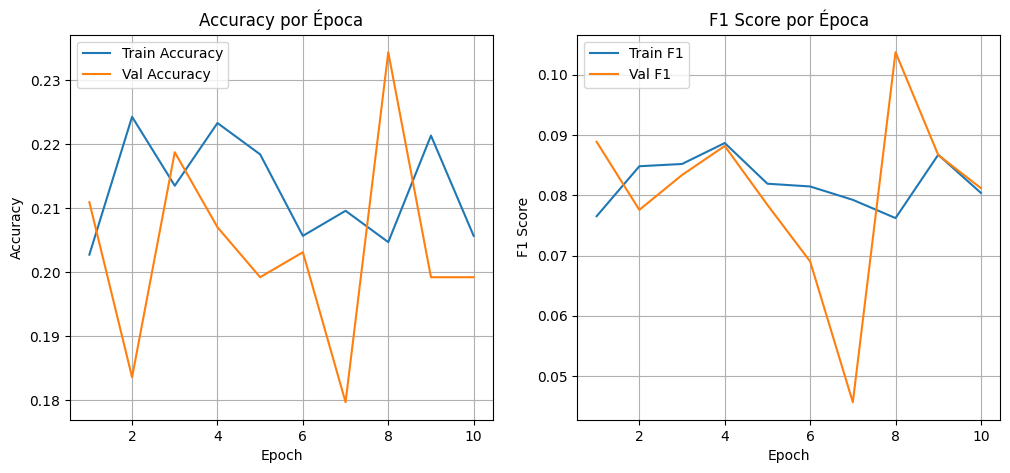

In [ ]:
# Listas para guardar métricas
train_acc_list, val_acc_list = [], []
train_f1_list, val_f1_list = [], []
model.train()
classifier_head.train()
for epoch in range(epochs):
    
    

    running_loss = 0.0
    train_preds, train_labels = [], []

    for spectra, labels in train_loader:
        spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
        optimizer.zero_grad()

        
        emb = model.spectrum_encoder(spectra)["embedding"]

        logits = classifier_head(emb)
       # print(logits.shape)
        logits = logits[:, 0, :] 
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    train_acc_list.append(train_acc)
    train_f1_list.append(train_f1)

    # ---- VALIDATION ----
    model.eval()
    classifier_head.eval()

    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for spectra, labels in test_loader:
            spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
            emb = model.spectrum_encoder(spectra)["embedding"]
            logits = classifier_head(emb)
            logits = logits[:, 0, :] 
            loss = criterion(logits, labels)
            val_loss += loss.item()

            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_acc_list.append(val_acc)
    val_f1_list.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ---- GRAFICAR METRICAS ----
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_acc_list, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por Época")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_f1_list, label="Train F1")
plt.plot(range(1, epochs+1), val_f1_list, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score por Época")
plt.legend()
plt.grid(True)

plt.show()
